<a href="https://colab.research.google.com/github/keermani006/MACHINE-LEARNING/blob/main/LAB-1/ML_LAB_1_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Taxi Fare Prediction Using Machine Learning

## Objective

Build a machine learning algorithm that can predict the fare of a taxi ride in the city of Chicago, Illinois based on the data in the City of Chicago Taxi Trips dataset.

## Problem Statement

This is a problem of **Supervised Machine Learning - Regression**.

Target Variable is:

**Fare**

The machine learning model will be able to understand the relationship between the different features of a taxi ride and predict the fare of a taxi ride.

In [1]:
# ============================================
# 1. IMPORT LIBRARIES
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# ============================================
# 2. LOAD DATASET
# ============================================
url = "https://data.cityofchicago.org/resource/ajtu-isnz.json?$limit=50000"

df = pd.read_json(url)

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

Dataset loaded successfully!
Shape of dataset: (50000, 23)


In [3]:
# ============================================
# 3. DATASET OVERVIEW
# ============================================
df.head()

,trip_id,taxi_id,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,pickup_community_area,dropoff_community_area,fare,tips,...,payment_type,company,pickup_centroid_latitude,pickup_centroid_longitude,pickup_centroid_location,dropoff_centroid_latitude,dropoff_centroid_longitude,dropoff_centroid_location,pickup_census_tract,dropoff_census_tract
0,9ee522deb87e94ac069a3fa74e8e75e01e39735d,045270ae331ab61646c36aaf542de0077e97a5b0294e29...,2026-08-01T00:00:00.000,2026-08-01T00:00:00.000,465.0,2.08,25.0,23.0,9.51,0.00,...,Mobile,Flash Cab,41.890609,-87.756047,"{'type': 'Point', 'coordinates': [-87.75604671...",41.900070,-87.720918,"{'type': 'Point', 'coordinates': [-87.72091823...",NaN,NaN
1,3d6956def4051a751fd795eaffc7658d79dc0656,41ba5cfc7d59a833c94ed0b59fcc8a5f3aa5ca1b291325...,2026-08-01T00:00:00.000,2026-08-01T00:00:00.000,552.0,1.30,32.0,8.0,8.03,0.00,...,Mobile,City Service,41.878866,-87.625192,"{'type': 'Point', 'coordinates': [-87.62519214...",41.899602,-87.633308,"{'type': 'Point', 'coordinates': [-87.63330803...",NaN,NaN
2,1440b4937ebeff23ef5040bc1b5a3ea2f1f6230e,3324712c665e5b70d271ba8f48ae939f361e0caf35973b...,2026-08-01T00:00:00.000,2026-08-01T00:15:00.000,731.0,1.70,32.0,32.0,10.53,0.00,...,Mobile,Flash Cab,41.871016,-87.631407,"{'type': 'Point', 'coordinates': [-87.63140652...",41.884987,-87.620993,"{'type': 'Point', 'coordinates': [-87.62099291...",1.703184e+10,1.703132e+10
3,db461694caa0b1765765662ccf3e25344e1e8655,57f4e1888791b2147f4c4add8f476ac881451d6eef6dca...,2026-08-01T00:00:00.000,2026-08-01T00:15:00.000,893.0,4.35,8.0,6.0,17.06,4.65,...,Mobile,City Service,41.899602,-87.633308,"{'type': 'Point', 'coordinates': [-87.63330803...",41.944227,-87.655998,"{'type': 'Point', 'coordinates': [-87.65599818...",NaN,NaN
4,f03b88c14e2d6a19a2296f711dcf8a8230830ce8,84522a85ee58de9e1dfd59459786cf9459b11889128b6a...,2026-08-01T00:00:00.000,2026-08-01T00:15:00.000,1560.0,17.00,76.0,NaN,51.30,0.00,...,Credit Card,Transit Administrative Center Inc,41.979071,-87.903040,"{'type': 'Point', 'coordinates': [-87.90303966...",NaN,NaN,NaN,1.703198e+10,NaN


In [4]:
# ============================================
# 4. DATASET DIMENSIONS AND COLUMNS
# ============================================
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

Number of rows: 50000
Number of columns: 23

Column names:
['trip_id', 'taxi_id', 'trip_start_timestamp', 'trip_end_timestamp', 'trip_seconds', 'trip_miles', 'pickup_community_area', 'dropoff_community_area', 'fare', 'tips', 'tolls', 'extras', 'trip_total', 'payment_type', 'company', 'pickup_centroid_latitude', 'pickup_centroid_longitude', 'pickup_centroid_location', 'dropoff_centroid_latitude', 'dropoff_centroid_longitude', 'dropoff_centroid_location', 'pickup_census_tract', 'dropoff_census_tract']


In [5]:
# ============================================
# 5. DATASET INFORMATION
# ============================================
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   trip_id                     50000 non-null  object 
 1   taxi_id                     50000 non-null  object 
 2   trip_start_timestamp        50000 non-null  object 
 3   trip_end_timestamp          49999 non-null  object 
 4   trip_seconds                49995 non-null  float64
 5   trip_miles                  49997 non-null  float64
 6   pickup_community_area       48991 non-null  float64
 7   dropoff_community_area      46087 non-null  float64
 8   fare                        49932 non-null  float64
 9   tips                        49932 non-null  float64
 10  tolls                       49932 non-null  float64
 11  extras                      49932 non-null  float64
 12  trip_total                  49932 non-null  float64
 13  payment_type                500

In [6]:
# ============================================
# 6. DESCRIPTIVE STATISTICS
# ============================================
df.describe()

,trip_seconds,trip_miles,pickup_community_area,dropoff_community_area,fare,tips,tolls,extras,trip_total,pickup_centroid_latitude,pickup_centroid_longitude,dropoff_centroid_latitude,dropoff_centroid_longitude,pickup_census_tract,dropoff_census_tract
count,49995.000000,49997.000000,48991.000000,46087.000000,49932.000000,49932.000000,49932.000000,49932.000000,49932.000000,49011.000000,49011.000000,46455.000000,46455.000000,2.409800e+04,2.350600e+04
mean,1298.307491,6.086216,33.173583,23.790678,24.329448,2.980598,0.066204,3.295769,31.000886,41.905029,-87.695005,41.895757,-87.656366,1.703147e+10,1.703139e+10
std,1522.610132,7.296777,25.738647,19.087998,45.567531,4.859916,0.937475,9.123718,49.198604,0.056097,0.109867,0.048953,0.064736,3.707233e+05,3.372883e+05
min,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,41.660136,-87.913625,41.660136,-87.913625,1.703102e+10,1.703101e+10
25%,540.000000,1.200000,8.000000,8.000000,9.360000,0.000000,0.000000,0.000000,11.650000,41.879255,-87.695013,41.878866,-87.657233,1.703108e+10,1.703108e+10
50%,926.000000,2.900000,32.000000,24.000000,15.010000,0.000000,0.000000,0.000000,18.190000,41.895033,-87.642498,41.892508,-87.633308,1.703132e+10,1.703132e+10
75%,1680.000000,9.700000,51.000000,32.000000,34.560000,4.000000,0.000000,3.500000,42.862500,41.953582,-87.625192,41.922083,-87.625192,1.703184e+10,1.703183e+10
max,81918.000000,466.120000,77.000000,77.000000,4000.000000,90.000000,67.000000,251.500000,4000.000000,42.009623,-87.534903,42.015697,-87.534903,1.703198e+10,1.703198e+10


In [7]:
# ============================================
# 7. CHECK MISSING VALUES
# ============================================
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
trip_id                           0
taxi_id                           0
trip_start_timestamp              0
trip_end_timestamp                1
trip_seconds                      5
trip_miles                        3
pickup_community_area          1009
dropoff_community_area         3913
fare                             68
tips                             68
tolls                            68
extras                           68
trip_total                       68
payment_type                      0
company                           0
pickup_centroid_latitude        989
pickup_centroid_longitude       989
pickup_centroid_location        989
dropoff_centroid_latitude      3545
dropoff_centroid_longitude     3545
dropoff_centroid_location      3545
pickup_census_tract           25902
dropoff_census_tract          26494
dtype: int64


In [8]:
# ============================================
# 8. FEATURE AND TARGET SELECTION
# ============================================
features = [
    "trip_seconds",
    "trip_miles",
    "pickup_community_area",
    "dropoff_community_area"
]

target = "fare"

df = df[features + [target]]

df.head()

,trip_seconds,trip_miles,pickup_community_area,dropoff_community_area,fare
0,465.0,2.08,25.0,23.0,9.51
1,552.0,1.30,32.0,8.0,8.03
2,731.0,1.70,32.0,32.0,10.53
3,893.0,4.35,8.0,6.0,17.06
4,1560.0,17.00,76.0,NaN,51.30


In [9]:
# ============================================
# 9. CHECK MISSING VALUES AFTER SELECTION
# ============================================
print(df.isnull().sum())

trip_seconds                 5
trip_miles                   3
pickup_community_area     1009
dropoff_community_area    3913
fare                        68
dtype: int64


In [10]:
# ============================================
# 10. HANDLE MISSING VALUES
# ============================================
df = df.dropna()

print("Shape after removing missing values:", df.shape)

Shape after removing missing values: (45608, 5)


In [11]:
# ============================================
# 11. REMOVE INVALID VALUES
# ============================================
df = df[
    (df["trip_seconds"] > 0) &
    (df["trip_miles"] > 0) &
    (df["fare"] > 0)
]

print("Shape after removing invalid values:", df.shape)

Shape after removing invalid values: (42911, 5)


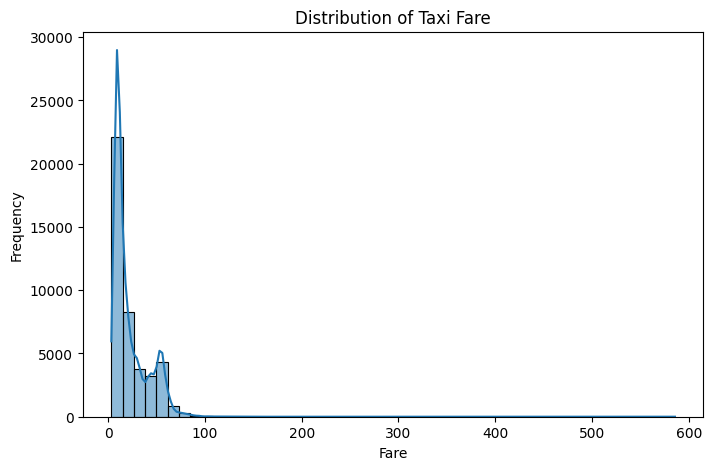

In [12]:
# ============================================
# 12. VISUALIZE FARE DISTRIBUTION
# ============================================
plt.figure(figsize=(8, 5))

sns.histplot(df["fare"], bins=50, kde=True)

plt.title("Distribution of Taxi Fare")
plt.xlabel("Fare")
plt.ylabel("Frequency")

plt.show()

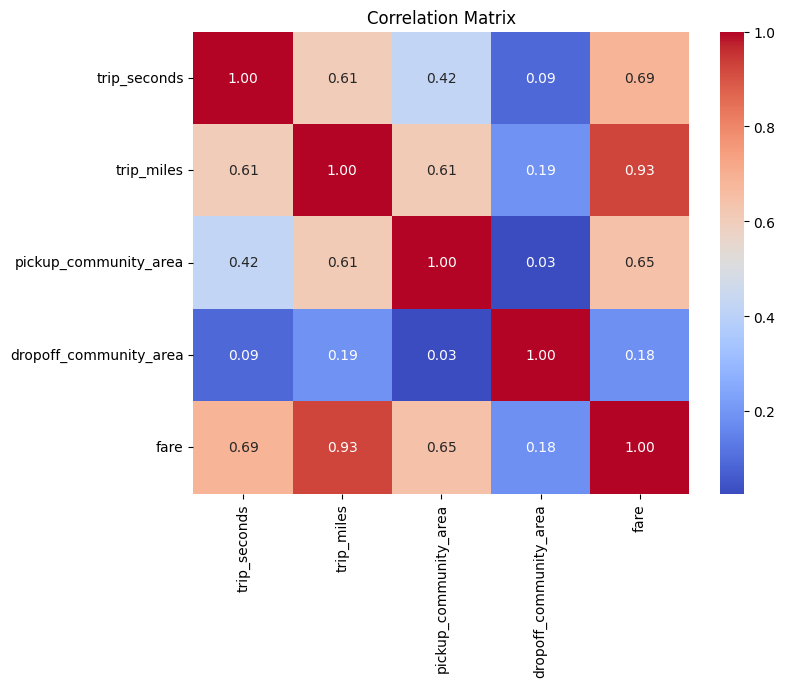

In [13]:
# ============================================
# 13. PLOT CORRELATION MATRIX
# ============================================
plt.figure(figsize=(8, 6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

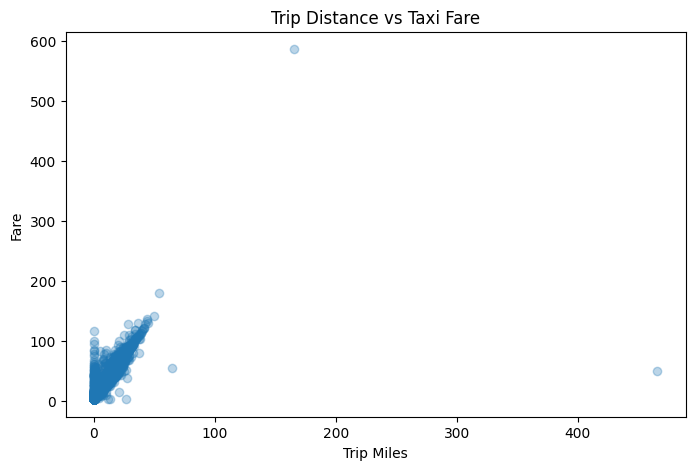

In [14]:
# ============================================
# 14. PLOT TRIP DISTANCE VS FARE
# ============================================
plt.figure(figsize=(8, 5))

plt.scatter(
    df["trip_miles"],
    df["fare"],
    alpha=0.3
)

plt.xlabel("Trip Miles")
plt.ylabel("Fare")
plt.title("Trip Distance vs Taxi Fare")

plt.show()

In [15]:
# ============================================
# 15. DEFINE FEATURES AND TARGET
# ============================================
X = df[features]
y = df[target]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   trip_seconds  trip_miles  pickup_community_area  dropoff_community_area
0         465.0        2.08                   25.0                    23.0
1         552.0        1.30                   32.0                     8.0
2         731.0        1.70                   32.0                    32.0
3         893.0        4.35                    8.0                     6.0
5         812.0        3.34                    2.0                    77.0

Target:
0     9.51
1     8.03
2    10.53
3    17.06
5    13.70
Name: fare, dtype: float64


In [16]:
# ============================================
# 16. TRAIN TEST SPLIT
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (34328, 4)
Testing data: (8583, 4)


In [17]:
# ============================================
# 17. FEATURE SCALING
# ============================================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [18]:
# ============================================
# 18. MODEL TRAINING
# ============================================
model = LinearRegression()

model.fit(X_train_scaled, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [19]:
# ============================================
# 19. MODEL PREDICTION
# ============================================
y_pred = model.predict(X_test_scaled)

print("Predictions generated successfully.")

print("\nFirst 10 predictions:")
print(y_pred[:10])

Predictions generated successfully.

First 10 predictions:
[43.5398352  16.22001807  7.4787415  17.31379753 14.38119679 17.47841309
 14.36858942 12.84484269 22.2416413  16.73126957]


In [20]:
# ============================================
# 20. COMPARE ACTUAL VS PREDICTED
# ============================================
comparison = pd.DataFrame({
    "Actual Fare": y_test.values[:10],
    "Predicted Fare": y_pred[:10]
})

comparison

,Actual Fare,Predicted Fare
0,43.24,43.539835
1,22.96,16.220018
2,6.35,7.478742
3,20.61,17.313798
4,8.97,14.381197
5,19.68,17.478413
6,15.07,14.368589
7,12.98,12.844843
8,25.94,22.241641
9,18.01,16.731270


In [21]:
# ============================================
# 21. CALCULATE MAE
# ============================================
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 2.6903911008614387


In [22]:
# ============================================
# 22. CALCULATE MSE
# ============================================
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 20.178002013041535


In [23]:
# ============================================
# 23. CALCULATE RMSE
# ============================================
rmse = np.sqrt(mse)

print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 4.4919931002887274


In [24]:
# ============================================
# 24. CALCULATE R2 SCORE
# ============================================
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.944324247481306


In [25]:
# ============================================
# 25. SUMMARIZE MODEL EVALUATION METRICS
# ============================================
print("Model Evaluation")
print("----------------------------")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Model Evaluation
----------------------------
Mean Absolute Error (MAE): 2.6903911008614387
Mean Squared Error (MSE): 20.178002013041535
Root Mean Squared Error (RMSE): 4.4919931002887274
R² Score: 0.944324247481306


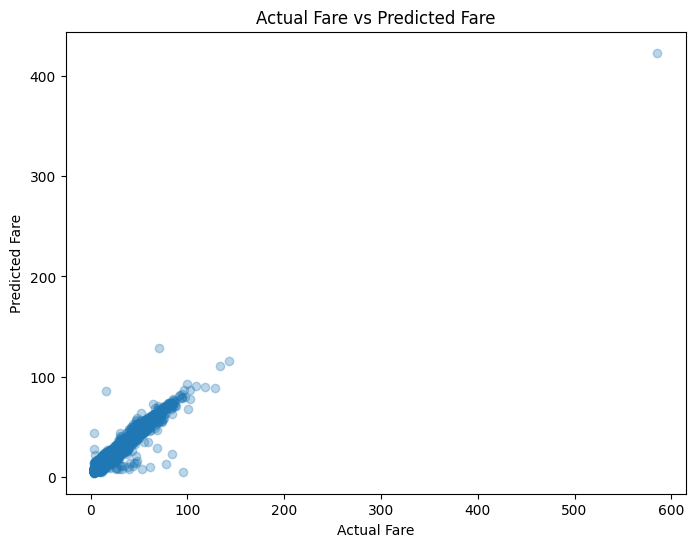

In [26]:
# ============================================
# 26. PLOT ACTUAL VS PREDICTED FARE
# ============================================
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.3
)

plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Actual Fare vs Predicted Fare")

plt.show()

In [27]:
# ============================================
# 27. NEW TAXI FARE PREDICTION
# ============================================
new_trip = pd.DataFrame({
    "trip_seconds": [1200],
    "trip_miles": [5],
    "pickup_community_area": [8],
    "dropoff_community_area": [32]
})

new_trip_scaled = scaler.transform(new_trip)

predicted_fare = model.predict(new_trip_scaled)

print("Predicted Taxi Fare: $", round(predicted_fare[0], 2))

Predicted Taxi Fare: $ 18.3


In [28]:
# ============================================
# 28. EXAMINE MODEL COEFFICIENTS
# ============================================
coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,trip_seconds,3.315622
1,trip_miles,12.729917
2,pickup_community_area,2.535585
3,dropoff_community_area,0.514108


# Conclusion

In this project, a Linear Regression model was built using Machine Learning techniques for predicting the fare of taxi rides in the city of Chicago using the City of Chicago Taxi Trips Dataset.

At the outset, the dataset was explored and preprocessed to remove missing values and irrelevant records. Trip duration, trip distance, pickup community area, and drop-off community area were identified as relevant features.

After partitioning the data into training and testing datasets, the features were standardized and used for training the Linear Regression model.

The performance metrics of the model were calculated using:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

The trained model can be further used to predict the fare of a new taxi ride using its trip features.

Hence, Machine Learning techniques can be used for estimating taxi fares from trip features.